<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/The_big_dataset_of_ultra_marathon_running.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns

df=pd.read_csv('TWO_CENTURIES_OF_UM_RACES.csv')
df.shape

(57344, 13)

In [ ]:
df.head()

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0.0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1.0
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2.0
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976,3.0
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469,4.0


In [4]:
df.dtypes

,0
Year of event,int64
Event dates,object
Event name,object
Event distance/length,object
Event number of finishers,int64
Athlete performance,object
Athlete club,object
Athlete country,object
Athlete year of birth,float64
Athlete gender,object


In [5]:
#clean up data
#only want usa races, 50k or 50mi, 2020
#50k
df[df['Event distance/length']=='50km']

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0.0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1.0
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2.0
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976,3.0
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57339,2018,10.02.2018,Taipei 6hr Ultra Marathon Saturday Run - 50km ...,50km,42,5:50:51 h,NaN,TPE,1972.0,M,M45,8.551,51264.0
57340,2018,10.02.2018,Taipei 6hr Ultra Marathon Saturday Run - 50km ...,50km,42,5:56:00 h,NaN,TPE,NaN,M,NaN,8.427,51265.0
57341,2018,10.02.2018,Taipei 6hr Ultra Marathon Saturday Run - 50km ...,50km,42,5:56:08 h,NaN,TPE,1976.0,M,M40,8.424,51266.0
57342,2018,10.02.2018,Taipei 6hr Ultra Marathon Saturday Run - 50km ...,50km,42,5:57:23 h,NaN,TPE,1974.0,M,M40,8.394,4811.0


In [6]:
df[
    df['Event distance/length']
        .str.lower()
        .str.strip()
        .isin(['50km', '50mi'])
    &
    (df['Year of event'] == 2018)
]


,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0.0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1.0
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2.0
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976,3.0
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57339,2018,10.02.2018,Taipei 6hr Ultra Marathon Saturday Run - 50km ...,50km,42,5:50:51 h,NaN,TPE,1972.0,M,M45,8.551,51264.0
57340,2018,10.02.2018,Taipei 6hr Ultra Marathon Saturday Run - 50km ...,50km,42,5:56:00 h,NaN,TPE,NaN,M,NaN,8.427,51265.0
57341,2018,10.02.2018,Taipei 6hr Ultra Marathon Saturday Run - 50km ...,50km,42,5:56:08 h,NaN,TPE,1976.0,M,M40,8.424,51266.0
57342,2018,10.02.2018,Taipei 6hr Ultra Marathon Saturday Run - 50km ...,50km,42,5:57:23 h,NaN,TPE,1974.0,M,M40,8.394,4811.0


In [7]:
df[df['Event name']=='Everglades 50 Mile Ultra Run (USA)']['Event name'].str.split('(').str.get(1).str.split(')')

,Event name
51923,"[USA, ]"
51924,"[USA, ]"
51925,"[USA, ]"
51926,"[USA, ]"
51927,"[USA, ]"
51928,"[USA, ]"
51929,"[USA, ]"
51930,"[USA, ]"
51931,"[USA, ]"
51932,"[USA, ]"


In [8]:
df[df['Event name'].str.split('(').str.get(1).str.split(')').str.get(0)=='USA']

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
55,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,9:53:05 h,"*Middleville, MI",USA,1983.0,M,M23,8.141,55.0
56,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,11:09:35 h,"*Waterloo, ON",CAN,1977.0,F,W40,7.211,56.0
57,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,11:33:00 h,"*Kitchener, ON",CAN,1976.0,M,M40,6.967,57.0
58,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,11:38:17 h,"*Utica, MI",USA,1986.0,M,M23,6.914,58.0
59,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9,11:56:35 h,"*Grass Lake, MI",USA,1988.0,M,M23,6.738,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56973,2018,10.-11.02.2018,Donna 110 Ultra Marathon (USA),110mi/2Etappen,6,17:29:56 h,NaN,USA,1980.0,M,M35,10.117,51189.0
56974,2018,10.-11.02.2018,Donna 110 Ultra Marathon (USA),110mi/2Etappen,6,23:15:48 h,NaN,GER,1967.0,M,M50,7.61,51190.0
56975,2018,10.-11.02.2018,Donna 110 Ultra Marathon (USA),110mi/2Etappen,6,25:48:52 h,NaN,USA,1976.0,M,M40,6.858,51191.0
56976,2018,10.-11.02.2018,Donna 110 Ultra Marathon (USA),110mi/2Etappen,6,27:21:57 h,NaN,USA,1964.0,M,M50,6.469,51192.0


In [9]:
#combine all the filters together
df_filtered = df[
    df['Event distance/length']
        .str.lower()
        .str.strip()
        .isin(['50km', '50mi'])
    &
    (df['Year of event'] == 2018)
    &
    (
        df['Event name']
        .str.split('(').str.get(1)
        .str.split(')').str.get(0)
        == 'USA'
    )
]



In [35]:
df_filtered

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
55,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9.0,9:53:05 h,"*Middleville, MI",USA,1983.0,M,M23,8.141,55.0
56,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9.0,11:09:35 h,"*Waterloo, ON",CAN,1977.0,F,W40,7.211,56.0
57,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9.0,11:33:00 h,"*Kitchener, ON",CAN,1976.0,M,M40,6.967,57.0
58,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9.0,11:38:17 h,"*Utica, MI",USA,1986.0,M,M23,6.914,58.0
59,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge (USA),50mi,9.0,11:56:35 h,"*Grass Lake, MI",USA,1988.0,M,M23,6.738,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
661478,2018,27.-28.10.2018,Cactus Rose 50 Mile (USA),50mi,29.0,17:05:58 h,NaN,USA,1972.0,M,M45,4.706,68122.0
661479,2018,27.-28.10.2018,Cactus Rose 50 Mile (USA),50mi,29.0,18:13:01 h,NaN,USA,1953.0,M,M65,4.417,23336.0
661480,2018,27.-28.10.2018,Cactus Rose 50 Mile (USA),50mi,29.0,18:49:58 h,NaN,USA,1986.0,M,M23,4.273,375022.0
661481,2018,27.-28.10.2018,Cactus Rose 50 Mile (USA),50mi,29.0,23:30:00 h,NaN,USA,1952.0,M,M65,3.424,68273.0


In [10]:
#remove (USA) from event name
df_filtered['Event name']=df_filtered['Event name'].str.split('(').str.get(0)


/tmp/ipython-input-3383963042.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Event name']=df_filtered['Event name'].str.split('(').str.get(0)


In [11]:
df_filtered.head()

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
55,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,9:53:05 h,"*Middleville, MI",USA,1983.0,M,M23,8.141,55.0
56,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:09:35 h,"*Waterloo, ON",CAN,1977.0,F,W40,7.211,56.0
57,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:33:00 h,"*Kitchener, ON",CAN,1976.0,M,M40,6.967,57.0
58,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:38:17 h,"*Utica, MI",USA,1986.0,M,M23,6.914,58.0
59,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:56:35 h,"*Grass Lake, MI",USA,1988.0,M,M23,6.738,59.0


In [12]:
#clean up athlete age
df_filtered['athlete_age']=2020-df_filtered['Athlete year of birth']

/tmp/ipython-input-4082821463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['athlete_age']=2020-df_filtered['Athlete year of birth']


In [13]:
df_filtered.loc[:, 'Athlete performance'] = (
    df_filtered['Athlete performance']
    .str.split(' ')
    .str.get(0)
)

In [14]:
df_filtered.head()

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID,athlete_age
55,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,9:53:05,"*Middleville, MI",USA,1983.0,M,M23,8.141,55.0,37.0
56,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:09:35,"*Waterloo, ON",CAN,1977.0,F,W40,7.211,56.0,43.0
57,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:33:00,"*Kitchener, ON",CAN,1976.0,M,M40,6.967,57.0,44.0
58,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:38:17,"*Utica, MI",USA,1986.0,M,M23,6.914,58.0,34.0
59,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:56:35,"*Grass Lake, MI",USA,1988.0,M,M23,6.738,59.0,32.0


In [15]:
#drop columns : athlete club, athlete country,athlete year, athlete age category
df2 = df_filtered.drop(
    columns=[
        'Athlete age category',
        'Athlete club',
        'Athlete country',
        'Athlete year of birth'
    ]
)

df2.head()


,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,athlete_age
55,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,9:53:05,M,8.141,55.0,37.0
56,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:09:35,F,7.211,56.0,43.0
57,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:33:00,M,6.967,57.0,44.0
58,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:38:17,M,6.914,58.0,34.0
59,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:56:35,M,6.738,59.0,32.0


In [16]:
#clean up null calues
df2.isna().sum()

,0
Year of event,0
Event dates,0
Event name,0
Event distance/length,0
Event number of finishers,0
Athlete performance,0
Athlete gender,0
Athlete average speed,0
Athlete ID,0
athlete_age,38


In [17]:
df2[df2['athlete_age'].isna()==1]

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,athlete_age
453,2018,01.01.2018,Red Eye 50km,50km,21,5:10:00,M,9.677,453.0,NaN
456,2018,01.01.2018,Red Eye 50km,50km,21,5:44:00,M,8.721,456.0,NaN
459,2018,01.01.2018,Red Eye 50km,50km,21,6:07:00,M,8.174,459.0,NaN
460,2018,01.01.2018,Red Eye 50km,50km,21,6:12:00,M,8.065,460.0,NaN
13214,2018,17.03.2018,Lt. JC Stone 50K UltraMarathon,50km,34,4:54:43,F,10.179,12483.0,NaN
13215,2018,17.03.2018,Lt. JC Stone 50K UltraMarathon,50km,34,5:16:56,M,9.466,12484.0,NaN
20023,2018,17.03.2018,Three Days of Syllamo 50 Mile Run,50mi,57,12:51:20,M,6.259,19222.0,NaN
20610,2018,16.03.2018,Three Days of Syllamo 50 km Run,50km,81,5:22:35,M,9.3,19222.0,NaN
21192,2018,11.03.2018,Fall Creek Falls 50K,50km,49,5:46:59,M,8.646,4033.0,NaN
25600,2018,10.03.2018,Prickly Pear 50K Trail Run,50km,39,5:49:26,M,8.585,24196.0,NaN


In [18]:
df2=df2.dropna()

In [66]:
df2.shape

(63724, 10)

In [19]:
df2[df2.duplicated()==True]


,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,athlete_age


In [20]:
#reset index
df2.reset_index(drop=True)

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,athlete_age
0,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,9:53:05,M,8.141,55.0,37.0
1,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:09:35,F,7.211,56.0,43.0
2,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:33:00,M,6.967,57.0,44.0
3,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:38:17,M,6.914,58.0,34.0
4,2018,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,11:56:35,M,6.738,59.0,32.0
...,...,...,...,...,...,...,...,...,...,...
6717,2018,10.02.2018,Black Warrior 50K,50km,57,8:45:13,F,5.712,12028.0,65.0
6718,2018,10.02.2018,Black Warrior 50K,50km,57,8:55:39,F,5.601,51145.0,51.0
6719,2018,10.02.2018,Black Warrior 50K,50km,57,8:56:06,M,5.596,51146.0,59.0
6720,2018,10.02.2018,Black Warrior 50K,50km,57,10:40:01,F,4.687,51147.0,43.0


In [21]:
#fix types
df2.dtypes

,0
Year of event,int64
Event dates,object
Event name,object
Event distance/length,object
Event number of finishers,int64
Athlete performance,object
Athlete gender,object
Athlete average speed,object
Athlete ID,float64
athlete_age,float64


In [23]:
df2['athlete_age']=df2['athlete_age'].astype(int)
df2['Athlete average speed']=df2['Athlete average speed'].astype(float)

In [24]:
df2.dtypes

,0
Year of event,int64
Event dates,object
Event name,object
Event distance/length,object
Event number of finishers,int64
Athlete performance,object
Athlete gender,object
Athlete average speed,float64
Athlete ID,float64
athlete_age,int64


In [25]:
#rename columns
#Year of event	int64
#Event dates	object
#Event name	object
#Event distance/length	object
#Event number of finishers	float64
#Athlete performance	object
#Athlete gender	object
#Athlete average speed	float64
#Athlete ID	float64

df2 = df2.rename(columns={
    'Year of event': 'year',
    'Event dates': 'race_day',
    'Event name': 'race_name',
    'Event distance/length': 'race_length',
    'Event number of finishers': 'race_number_of_finishers',
    'Athlete performance': 'athlete_performance',
    'Athlete gender': 'athlete_gender',
    'Athlete average speed': 'athlete_average_speed',
    'Athlete ID': 'athlete_id'
})



In [26]:
#reorder columns
df3=df3=df2[['race_day','race_name','race_length','race_number_of_finishers','athlete_id','athlete_gender','athlete_age','athlete_performance','athlete_average_speed']]

In [88]:
df3.head()

,race_day,race_name,race_length,race_number_of_finishers,athlete_id,athlete_gender,athlete_age,athlete_performance,athlete_average_speed
55,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9.0,55.0,M,37,9:53:05,8.141
56,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9.0,56.0,F,43,11:09:35,7.211
57,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9.0,57.0,M,44,11:33:00,6.967
58,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9.0,58.0,M,34,11:38:17,6.914
59,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9.0,59.0,M,32,11:56:35,6.738


In [27]:
#find 2 race i ran in 2020 Sarasota / Everglades
df3[df3['race_name']=='Everglades 50 Mile Ultra Run ']

,race_day,race_name,race_length,race_number_of_finishers,athlete_id,athlete_gender,athlete_age,athlete_performance,athlete_average_speed
51923,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,47601.0,M,40,7:00:00,11.495
51924,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,37220.0,M,31,8:29:48,9.470
51925,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,47602.0,M,41,8:45:31,9.187
51926,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,47603.0,M,53,9:01:52,8.910
51927,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,47604.0,M,34,9:26:06,8.529
51928,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,47605.0,M,42,9:40:18,8.320
51929,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,36476.0,M,56,9:42:43,8.285
51930,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,47606.0,M,51,9:55:37,8.106
51931,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,47607.0,M,44,9:58:07,8.072
51932,17.02.2018,Everglades 50 Mile Ultra Run,50mi,23,47608.0,M,39,10:21:15,7.771


In [28]:
df3['athlete_id']=df3['athlete_id'].astype(int)

df3[df3['athlete_id']==222509]

/tmp/ipython-input-3103692212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['athlete_id']=df3['athlete_id'].astype(int)


,race_day,race_name,race_length,race_number_of_finishers,athlete_id,athlete_gender,athlete_age,athlete_performance,athlete_average_speed


<Axes: xlabel='race_length', ylabel='Count'>

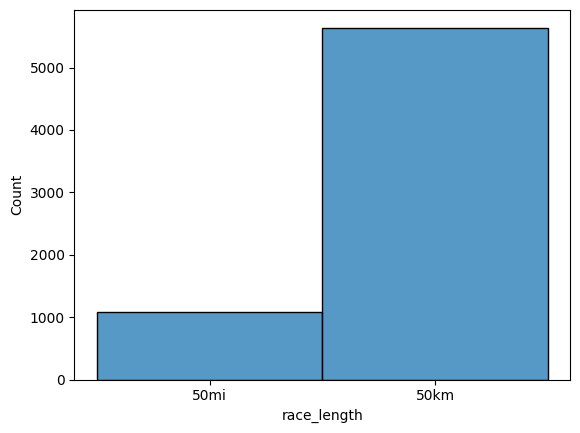

In [29]:
sns.histplot(df3['race_length'])

<Axes: xlabel='race_length', ylabel='Count'>

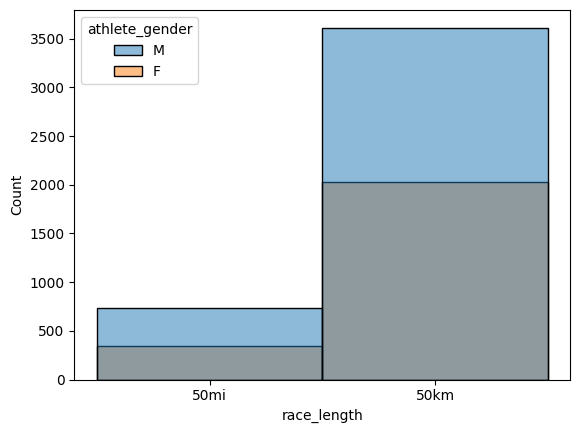

In [30]:
sns.histplot(df3,x='race_length',hue='athlete_gender')

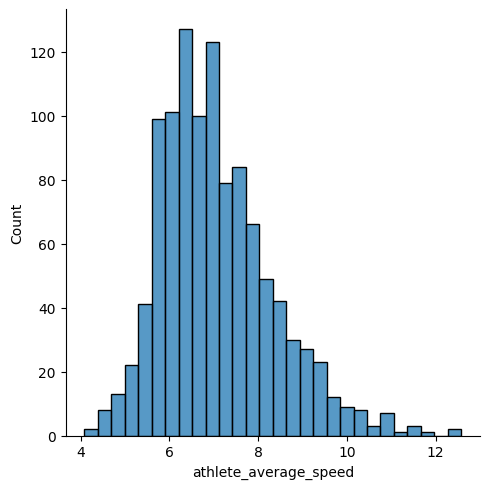

In [31]:
sns.displot(df3[df3['race_length']=='50mi']['athlete_average_speed'])

<Axes: xlabel='race_length', ylabel='athlete_average_speed'>

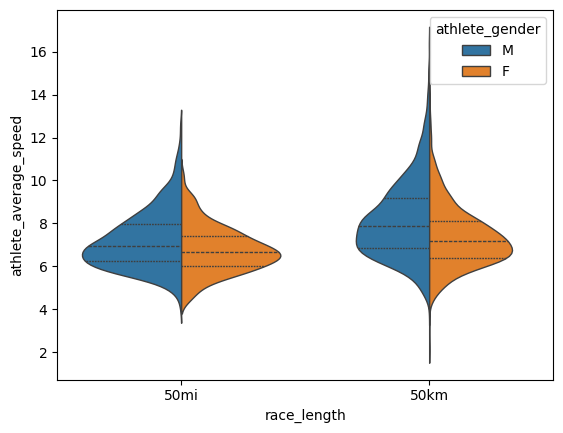

In [32]:
sns.violinplot(data=df3,x='race_length',y='athlete_average_speed',hue='athlete_gender',split=True,inner='quart',linewidth=1)

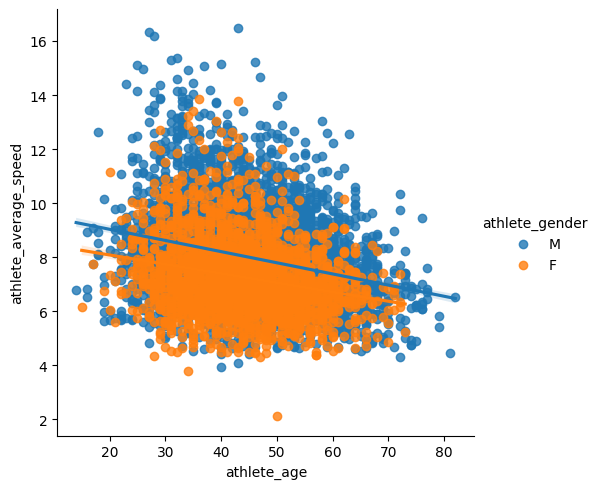

In [33]:
sns.lmplot(data=df3,x='athlete_age',y='athlete_average_speed',hue='athlete_gender')

In [35]:
df3.groupby(['race_length','athlete_gender'])['athlete_average_speed'].mean()

race_length  athlete_gender
50km         F                 7.362415
             M                 8.147365
50mi         F                 6.767781
             M                 7.207537
Name: athlete_average_speed, dtype: float64

In [36]:
#what age groups are the best in the 50 m race(20 +races min)
df3.query('race_length=="50mi"').groupby('athlete_age')['athlete_average_speed'].agg(['mean','count']).sort_values('mean',ascending=False).query('count>19')

,mean,count
athlete_age,,
33,7.825250,20
37,7.683806,36
30,7.595083,24
36,7.562000,33
40,7.403738,42
35,7.347583,24
32,7.316182,22
31,7.315261,23
43,7.307920,50


In [39]:
#seasons for the data -> slower in summer than winter
#spring 2-5
#Summer 6-11
#winter 12-2
#split between two decimals
df3['race_month']=df3['race_day'].str.split('.').str.get(1).astype(int)
df3.head()

,race_day,race_name,race_length,race_number_of_finishers,athlete_id,athlete_gender,athlete_age,athlete_performance,athlete_average_speed,race_month
55,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,55,M,37,9:53:05,8.141,1
56,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,56,F,43,11:09:35,7.211,1
57,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,57,M,44,11:33:00,6.967,1
58,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,58,M,34,11:38:17,6.914,1
59,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,59,M,32,11:56:35,6.738,1


In [42]:
df3['race_season']=df3['race_month'].apply(lambda x: 'winter' if x>11 else  'Fall' if x> 8 else 'Summer' if x>5 else 'Spring' if x>2 else 'winter' )
df3.head()

,race_day,race_name,race_length,race_number_of_finishers,athlete_id,athlete_gender,athlete_age,athlete_performance,athlete_average_speed,race_month,race_season
55,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,55,M,37,9:53:05,8.141,1,winter
56,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,56,F,43,11:09:35,7.211,1,winter
57,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,57,M,44,11:33:00,6.967,1,winter
58,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,58,M,34,11:38:17,6.914,1,winter
59,06.01.2018,Yankee Springs 50 Mile Winter Challenge,50mi,9,59,M,32,11:56:35,6.738,1,winter


In [43]:
df3.groupby('race_season')['athlete_average_speed'].agg(['mean','count']).sort_values('mean',ascending=False)

,mean,count
race_season,,
Spring,7.808821,3853
winter,7.640698,2869


In [44]:
#50 miler only
df3.query('race_length=="50mi"').groupby('race_season')['athlete_average_speed'].agg(['mean','count']).sort_values('mean',ascending=False)

,mean,count
race_season,,
Spring,7.142090,715
winter,6.924046,367
